In [3]:
import os
os.environ["HF_HOME"] = "/home/yandex/APDL2425a/group_12/gorodissky/.cache/huggingface"
print(f"HF_HOME set to:\t\t {os.environ['HF_HOME']}")

import torch
print(f"CUDA available: \t{torch.cuda.is_available()}")
print(f"Torch version: \t\t{torch.__version__}")
if torch.cuda.is_available():
    print(f"Number of CUDA devices\t {torch.cuda.device_count()}")
    print(f"CUDA device:\t\t {torch.cuda.get_device_name(torch.cuda.current_device())}")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import List
from sae.general import get_latest_cpt, get_current_timestamp
import pickle

model_to_colors = {
    "Qwen/Qwen2.5-7B-Instruct": "blue",
    "meta-llama/Llama-3.1-8B-Instruct": "orange",
    # "mistralai/Ministral-8B-Instruct-2410": "red",
    # "google/gemma-2-9b-it": "green",
}



HF_HOME set to:		 /home/yandex/APDL2425a/group_12/gorodissky/.cache/huggingface
CUDA available: 	True
Torch version: 		2.7.1+cu126
Number of CUDA devices	 4
CUDA device:		 NVIDIA GeForce GTX TITAN X


# Length
Predict length from prompt's last token using ridge regression

In [ ]:
from sae.general import eval

dataset_name = "allenai/WildChat-1M"
task = "lengths"
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for model_name, color in model_to_colors.items():
    print(f"Evaluating model: {model_name}")

    layers , rel_errs, scores = eval(
        model_name=model_name,
        task=task,
        dataset=dataset_name,
    )
    layers_ratio = [layer / max(layers) for layer in layers]
    # plot rel err
    axes[0].plot(layers_ratio, rel_errs, marker='o', color=color, label=model_name)
    axes[0].set_title(f"Predicting {task}")
    axes[0].set_xlabel("Layer (normalized)")
    axes[0].set_ylabel("% Relative Error ")
    axes[0].legend()
    axes[0].grid(True)

    # plot r2 scores
    axes[1].plot(layers_ratio, scores, marker='o', color=color, label=model_name)
    axes[1].set_title(f"Predicting {task}")
    axes[1].set_xlabel("Layer (normalized)")
    axes[1].set_ylabel("R2 Score")
    axes[1].legend()
    axes[1].grid(True)
    
    rel_errs = np.array(rel_errs)
    layers = np.array(layers)
    sorted_indices = np.argsort(rel_errs)
    sorted_rel_errs = rel_errs[sorted_indices]
    sorted_layers = layers[sorted_indices]
    print("Best layers:", sorted_layers[:3], "with errors:", sorted_rel_errs[:3])


plt.tight_layout()
plt.show()

# STOP
Route questions between big and small model depending on a correctness probe. <br>
The corretness probe was trained using difference in means between correct and incorrect clusters (activations are from the prompt's last token)

In [ ]:
from adais.adaptive.probe import CorrectnessScorer
from transformers import AutoTokenizer
from adais.datasets import mmlu_pro
from sae.general import stop_expr, get_latest_cpt, stop_expr_random_baseline
dataset_name = "MMLU"
base_path = Path("/home/yandex/APDL2425a/group_12/gorodissky/sae/data")
small_model = "Qwen/Qwen2.5-3B-Instruct"
path_small = base_path / "qa" / dataset_name / small_model
path_small = path_small / get_latest_cpt(path_small) / "qa_dataset.pkl"


big_model = "Qwen/Qwen2.5-14B-Instruct"
path_big = base_path / "qa" / dataset_name / big_model
path_big = path_big / get_latest_cpt(path_big) / "qa_dataset.pkl"

qa_df_small = pd.read_pickle(str(path_small))
qa_df_big = pd.read_pickle(str(path_big))
# probes_base_path = "/home/yandex/APDL2425a/group_12/gorodissky/AdaIS/output/probe_results"
# probe = CorrectnessScorer.load(f"{probes_base_path}/{dataset_name}/{small_model}/correctness_scorer_2026-02-12_18:40.npz")
probe = CorrectnessScorer.load("/home/yandex/APDL2425a/group_12/gorodissky/AdaIS/output/probe_results/MMLU/Qwen/Qwen2.5-3B-Instruct/2026-02-16_17:06/correctness_scorer.npz")
tokenizer_small = AutoTokenizer.from_pretrained(small_model)
tokenizer_big = AutoTokenizer.from_pretrained(big_model)
cost_small = 3
cost_big = 14 
# thresholds = np.linspace(0.4, 0.6, 11)
# thresholds = list(thresholds)
# thresholds.append(1.0) # add the extreme point where we always use the small model
# thresholds = [0.0] + thresholds # add the extreme point where we always use the big model
# thresholds = [0.5]
ps = np.linspace(0.0, 1.0, 11)
cs = ps * 0.4 + 0.8
print(cs)
accs = []
accs_baseline = []
costs = []
costs_baseline = []
for c in cs:
    accuracy, cost, used_small_ratio = stop_expr(
        qa_df_small=qa_df_small,
        qa_df_big=qa_df_big,
        probe=probe,
        tokenizer_small=tokenizer_small,
        tokenizer_big=tokenizer_big,
        c=c,
        cost_small=cost_small,
        cost_big=cost_big,
        extract_answer_func=mmlu_pro.get_final_answer
    )
    accs.append(accuracy)
    costs.append(cost)
    print(f"Accuracy: {accuracy:.4f}, Cost: {cost}, Used small model for: {used_small_ratio*100:.2f}% of questions")

num_repititions=10
acc_randoms = []
cost_randoms = []
for p in ps:
    accs_reps = []
    costs_reps = []
    for _ in range(num_repititions):
        accuracy_random, cost_random = stop_expr_random_baseline(
            qa_df_small=qa_df_small,
            qa_df_big=qa_df_big,
            cost_small=cost_small,
            cost_big=cost_big,
            tokenizer_small=tokenizer_small,
            tokenizer_big=tokenizer_big,
            extract_answer_func=mmlu_pro.get_final_answer,
            p=p,
            )
        accs_reps.append(accuracy_random)
        costs_reps.append(cost_random)
    acc_randoms.append(np.mean(accs_reps))
    cost_randoms.append(np.mean(costs_reps))



# thresholds = thresholds[1:-1] # remove 0.0 and 1.0 for plotting
fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(ps, accs, color="blue", marker="o")
ax1.plot(ps, acc_randoms, color="skyblue", marker="o", linestyle="--")
# ax1.axhline(y=accs_baseline[0], color="blue", linestyle="--", linewidth=2) # only small model
# ax1.axhline(y=accs_baseline[1], color="blue", linestyle="--", linewidth=2) # only big model
# ax1.axhline(y=acc_random, color="skyblue", linestyle="--", linewidth=2) # random baseline
ax1.set_xlabel("c")
ax1.set_ylabel("Accuracy", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")


ax2 = ax1.twinx()
ax2.plot(ps, costs, color="red", marker="^")
ax2.plot(ps, cost_randoms, color="salmon", marker="^", linestyle="--")
# ax2.axhline(y=costs_baseline[0], color="red", linestyle=":", linewidth=2) # only small model
# ax2.axhline(y=costs_baseline[1], color="red", linestyle=":", linewidth=2) # only big model
# ax2.axhline(y=cost_random, color="salmon", linestyle=":", linewidth=2) # random baseline
ax2.set_ylabel("Cost", color="red")
ax2.tick_params(axis="y", labelcolor="red")

ax1.grid(True)
plt.title("Accuracy & Cost vs c")
fig.text(0.5, -0.08, "Horizontal lines represent only small or only big model\nLight color represents random baseline", ha="center")
plt.show()

fig2, ax3 = plt.subplots(figsize=(7,4))
ax3.plot(cost_randoms, acc_randoms, color="blue", marker="o", label="Random")
ax3.plot(costs, accs, color="red", marker="^", label="Probe")
ax3.set_xlabel("Cost")
ax3.set_ylabel("Accuracy")
ax3.set_title("Accuracy vs Cost")
ax3.grid(True)
ax3.legend()
plt.show()

# Length (mean classification)

Predict length by discretizing length to bins and classifiy with closest mean

In [ ]:
def associate_to_bin(l: int, bins: List[int], width: int):
    for i, b in enumerate(bins):
        if l <= b + width:
            return i
    return i

def closest_bin(act ,bins_to_mean):
    min_bin = 0
    min_dist = float("inf") 
    for i, mean in bins_to_mean.items():
        dist = np.linalg.norm(mean - act)
        if dist < min_dist:
            min_dist = dist
            min_bin = i
    return min_bin


def evaluate_length_classification(base_path, k, model_name):
    print(f"Evaluating {model_name}...")
    path = base_path / model_name
    path /= get_latest_cpt(path)

    lengths = torch.load(str(path / "Y_lengths.pt"))
    valid_mask = lengths != -1
    print(f"Number of valid examples: {valid_mask.sum()}/{valid_mask.size(0)} ")
    lengths = lengths[valid_mask].numpy()
    low, high = np.quantile(lengths, [0.01, 0.99])
    width = (high - low)/k
    bins = torch.linspace(start=low, end=high, steps=k+1)[:-1] # discard the end
    save_path = base_path / model_name / "classification" / get_current_timestamp()
    os.makedirs(str(save_path), exist_ok=True)
    torch.save(bins, str(save_path / "bins.pt"))
    
    accs = []
    layers = [dir for dir in os.listdir(path) if "layer" in dir]
    for layer in layers:
        cur_path = path / layer
        acts = torch.load(str(cur_path))
        acts = acts[valid_mask]
        df = pd.DataFrame({
            "activation": list(acts.float().numpy()),
            "length": lengths
        })

        train_df, test_df = train_test_split(df, test_size=0.2, random_state=1337)
        train_df["bin"] = train_df["length"].apply(lambda l: associate_to_bin(l, bins, width))

        bins_to_mean = {}
        for i in range(len(bins)):
            acts = train_df[train_df["bin"] == i]["activation"]
            print(type(acts), len(acts))
            mean = acts.sum() / len(acts)
            bins_to_mean[i] = mean
        
        with open(save_path / f"{layer[:-3]}_means.pkl", "wb") as f:
            pickle.dump(bins_to_mean, f)
        
        test_df["true_bin"] = test_df["length"].apply(lambda l: associate_to_bin(l, bins=bins, width=width))
        test_df["pred_bin"] = test_df["activation"].apply(lambda a: closest_bin(a, bins_to_mean))
        acc = (test_df["pred_bin"] == test_df["true_bin"]).sum() / len(test_df)
        accs.append(acc)
        print(f"Layer {layer[:-3]} Acc:{acc:.2f}")
    
    return accs



k = 20
base_path = Path("../data/lengths/allenai/WildChat-1M") 
fig, axes = plt.subplots()
for model_name, color in model_to_colors.items():
    accs = evaluate_length_classification(base_path, k, model_name)
    layers_ratios = [layer / len(accs) for layer in range(len(accs))] 
    axes.plot(layers_ratios, accs, color=color, marker="o", linestyle="--", label=model_name)

axes.set_xlabel("Layer")
axes.set_ylabel("Acc (test set)")
axes.legend()
axes.set_title("Length classification (closest mean)")
axes.grid(True)
plt.tight_layout()
plt.show()

# Correctness classifaction (closet mean)

Evaluating Qwen/Qwen2.5-7B-Instruct...
activation_pre_mid Acc:0.72
activation_mid Acc:0.72
activation_post_mid Acc:0.72
Evaluating meta-llama/Llama-3.1-8B-Instruct...
activation_pre_mid Acc:0.71
activation_mid Acc:0.72
activation_post_mid Acc:0.72


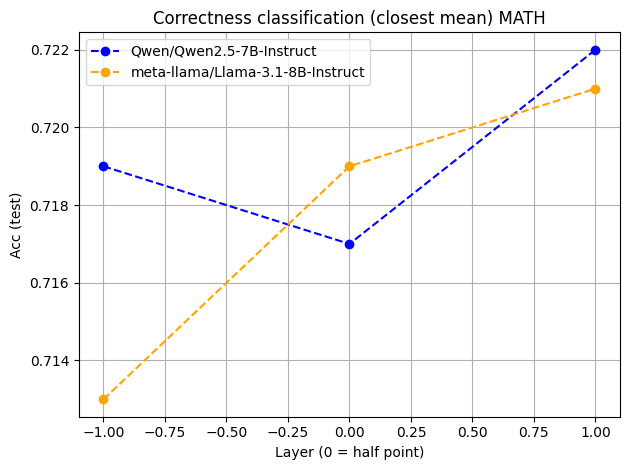

In [4]:
def closest_mean(act ,means):
    min_i = 0
    min_dist = float("inf") 
    for i, mean in means.items():
        dist = np.linalg.norm(mean - act)
        if dist < min_dist:
            min_dist = dist
            min_i = i
    return min_i

def evaluate_correctness_classification(base_path, model_name):
    print(f"Evaluating {model_name}...")
    path = base_path / model_name
    path /= get_latest_cpt(path)

    with open(path / "qa_dataset.pkl", "rb") as f:
        df = pickle.load(f)

    train_df, test_df =  train_test_split(df, test_size=0.2, random_state=1337)
    accs = []
    for act_name in ["activation_pre_mid", "activation_mid", "activation_post_mid"]:
        means = {}
        means[0] = train_df[act_name][~train_df["is_correct"]].sum() / (~train_df["is_correct"]).sum()
        means[1] = train_df[act_name][train_df["is_correct"]].sum() / (train_df["is_correct"]).sum()
    
        test_df["pred_is_correct"] = test_df[act_name].apply(lambda a: closest_mean(a, means))
        acc = (test_df["pred_is_correct"] == test_df["is_correct"]).sum() / len(test_df)
        accs.append(acc)
        print(f"{act_name} Acc:{acc:.2f}")
    
    return accs
base_path = Path("../data/qa/MATH")
fig, axes = plt.subplots()
for model_name, color in model_to_colors.items():
    layers = [-1, 0, 1]
    accs = evaluate_correctness_classification(base_path, model_name)
    axes.plot(layers, accs, color=color, marker="o", linestyle="--", label=model_name)

axes.set_xlabel("Layer (0 = half point)")
axes.set_ylabel("Acc (test)")
axes.legend()
axes.set_title("Correctness classification (closest mean) MATH")
axes.grid(True)
plt.tight_layout()
plt.show()